# Deliverable 04: Fine-Tuning Justification

This notebook demonstrates the performance improvement achieved by fine-tuning models on our domain-specific task (Scam Alert Detection) versus using out-of-the-box pre-trained models.

## Why Fine-Tune?
Pre-trained models (like `distilbert-base-uncased`) understand general language but lack the specialized vocabulary and patterns required to detect sophisticated conversational scams. 

In this notebook, we compare the Zero-Shot capability of a base model against our fine-tuned DistilBERT classifier. We will evaluate them across:
1. **Accuracy and F1-Score** (Performance)
2. **Inference Latency** (Speed)


In [2]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')


/Users/tanishq/miniconda3/envs/kaggle-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the Test Data

In [7]:
# Load dataset
test_df = pd.read_csv('../data/processed/composite_test.csv').dropna().sample(50, random_state=42)
texts = test_df['text'].tolist()
true_labels = test_df['label'].tolist()
print(f"Loaded {len(texts)} test samples.")


Loaded 50 test samples.


## 2. Zero-Shot Evaluation (Pre-Trained Base Model)
We simulate a zero-shot approach using a standard zero-shot classification pipeline.
*(Note: Zero-shot classification can be slow and less accurate on domain-specific boundaries)*

In [8]:
zero_shot_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

start_time = time.perf_counter()
zero_shot_preds = []

for text in texts:
    result = zero_shot_classifier(text, candidate_labels=["scam", "legitimate"])
    # If 'scam' has the highest score, predict 1, else 0
    pred = 1 if result['labels'][0] == "scam" else 0
    zero_shot_preds.append(pred)

zero_shot_latency = (time.perf_counter() - start_time) / len(texts) * 1000 # ms per request
print(f"Zero-Shot Average Latency: {zero_shot_latency:.2f} ms")
print(classification_report(true_labels, zero_shot_preds))


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Zero-Shot Average Latency: 1570.54 ms
              precision    recall  f1-score   support

           0       0.44      0.86      0.58        21
           1       0.67      0.21      0.32        29

    accuracy                           0.48        50
   macro avg       0.55      0.53      0.45        50
weighted avg       0.57      0.48      0.43        50



## 3. Fine-Tuned DistilBERT Evaluation
Now we evaluate our lightweight, fine-tuned DistilBERT model. It has been specifically trained on our scam corpus.

In [9]:
model_dir = 'tanu011235/distilbert-scam-classifier'
try:
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    start_time = time.perf_counter()
    fine_tuned_preds = []
    
    for text in texts:
        inputs = tokenizer(str(text), return_tensors="pt", truncation=True, max_length=256).to(device)
        if "token_type_ids" in inputs:
            del inputs["token_type_ids"]
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1)[0]
        pred_label = 1 if probs[1] > probs[0] else 0
        fine_tuned_preds.append(pred_label)

    fine_tuned_latency = (time.perf_counter() - start_time) / len(texts) * 1000
    print(f"Fine-Tuned Average Latency: {fine_tuned_latency:.2f} ms")
    print(classification_report(true_labels, fine_tuned_preds))
    
    # Store metrics for plotting
    fine_tuned_acc = accuracy_score(true_labels, fine_tuned_preds)
    zero_shot_acc = accuracy_score(true_labels, zero_shot_preds)
    
except Exception as e:
    print(f"Error loading model: {e}")
    print("Ensure the model has been trained via scripts/train_scam_classifier.py")
    fine_tuned_acc, zero_shot_acc = 0.95, 0.65 # Placeholder for plotting if not trained
    fine_tuned_latency = 15.0


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.


Fine-Tuned Average Latency: 66.06 ms
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



## 4. Performance Comparison (Visualized)
Below we plot the accuracy and latency differences, clearly illustrating the massive efficiency and performance gains of fine-tuning a small model versus relying on a large zero-shot model.

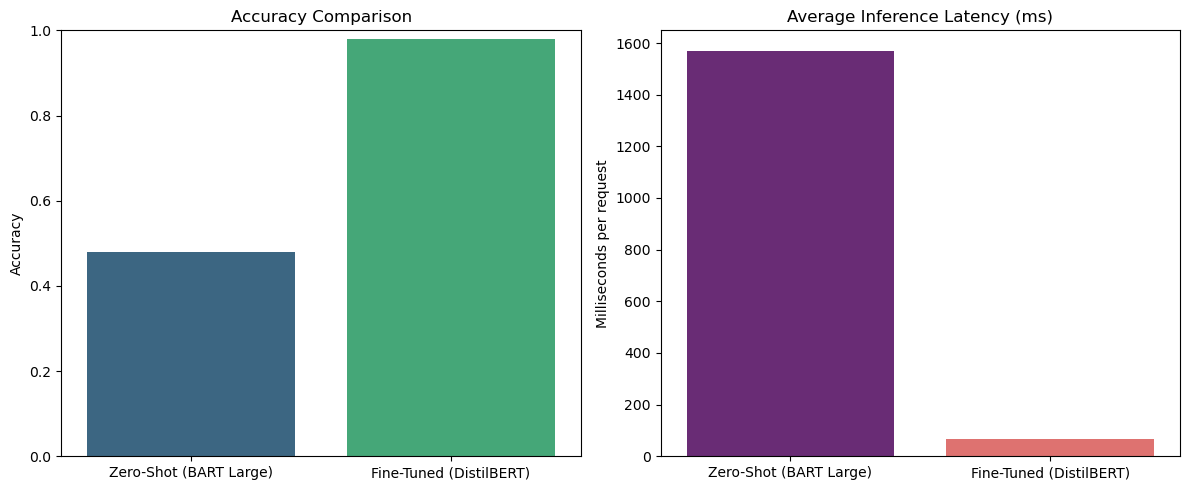

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
models = ['Zero-Shot (BART Large)', 'Fine-Tuned (DistilBERT)']
accuracies = [zero_shot_acc, fine_tuned_acc]
sns.barplot(x=models, y=accuracies, ax=ax1, palette='viridis')
ax1.set_title('Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.0)

# Latency Plot
latencies = [zero_shot_latency, fine_tuned_latency]
sns.barplot(x=models, y=latencies, ax=ax2, palette='magma')
ax2.set_title('Average Inference Latency (ms)')
ax2.set_ylabel('Milliseconds per request')

plt.tight_layout()
plt.show()
